# Customer Lifetime Value Prediction using BG/NBD and Gamma-Gamma Models

Predicting future customer value through probabilistic modeling and generating actionable business insights for customer retention and marketing strategies.

## 1. Business Understanding

### Business Objective

Customer retention is one of the biggest challenges for retail businesses. Since acquiring new customers is generally more expensive than retaining existing ones, understanding which customers are expected to generate the highest future value is essential.

The objective of this project is to predict Customer Lifetime Value (CLV) using transactional data from an online retail company. The results will help the business identify valuable customers, prioritize retention efforts, and optimize marketing strategies.

### Data Science Problem

This project aims to estimate the future economic value of each customer based on historical purchasing behavior.

To achieve this, two probabilistic models are used:

- **BG/NBD** to estimate future purchase frequency.
- **Gamma-Gamma** to estimate the expected monetary value of future purchases.

Together, these models allow us to estimate each customer's Customer Lifetime Value (CLV).

### Methodology

This project follows the **CRISP-DM** methodology:

1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Modeling
5. Evaluation
6. Business Recommendations

Each stage is documented and explained to simulate a real-world Data Science project.

# 2. Data Understanding

In this stage, we explore the transactional dataset to understand its structure, identify potential data quality issues, and determine the preprocessing steps required before modeling.

The analysis focuses on:
- Dataset dimensions
- Data types
- Missing values
- Duplicate records
- Descriptive statistics
- Initial business observations

In [ ]:
# Upload dataset
from google.colab import files
uploaded = files.upload()

Saving Online Retail.xlsx to Online Retail.xlsx


### 2.1 Dataset Overview

The Online Retail dataset contains transactional information from a UK-based online retailer. Each row represents a single product purchased within an invoice.

The objective of this first exploration is to understand the dataset structure before performing any cleaning or feature engineering.

In [ ]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df.shape

(541909, 8)

### 2.2 Dataset Structure

We inspect the dimensions, column names, and data types to verify that each variable has been correctly imported and to identify variables that may require preprocessing.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


### Initial Findings

- The dataset contains **541,909** transactional records and **8 variables**.
- Missing values are present in the **CustomerID** column, indicating that some transactions cannot be linked to a specific customer.
- The **Description** column also contains a small number of missing values.
- **InvoiceDate** was correctly imported as a datetime variable, which is essential for time-based analyses such as RFM and Customer Lifetime Value (CLV).
- **InvoiceNo** is stored as a categorical identifier (`object`), which is appropriate since invoice numbers are identifiers rather than numerical variables.

### 2.3 Descriptive Statistics

Descriptive statistics provide an initial overview of the numerical variables, allowing us to identify unusual values, potential outliers, and data quality issues before modeling.

In [ ]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


### Business Observations

The descriptive statistics reveal several important findings:

- Negative values were detected in **Quantity**, suggesting the presence of returned or cancelled transactions.
- Two negative values were identified in **UnitPrice**, requiring further investigation during data preparation.
- These observations indicate that not every transaction represents a successful sale, making it necessary to carefully distinguish purchases from returns before calculating revenue and Customer Lifetime Value.

## Basic Dataset Exploration

In [ ]:
df['CustomerID'].nunique()

4372

In [ ]:
df['InvoiceNo'].nunique()

25900

In [ ]:
df['Country'].value_counts().head(10)

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


# 3. Feature Engineering

### Revenue Calculation

Revenue is calculated as the product of the quantity purchased and the unit price of each transaction.

This variable represents the monetary value of every transaction and will later be aggregated at the customer level to support Customer Lifetime Value (CLV) modeling.



In [ ]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [ ]:
df['Revenue'].sum()

np.float64(9747747.933999998)

### Validation

The calculated revenue matches the expected transaction values, confirming that the new variable has been correctly created.

This feature will be fundamental for estimating customer spending and, ultimately, Customer Lifetime Value (CLV).

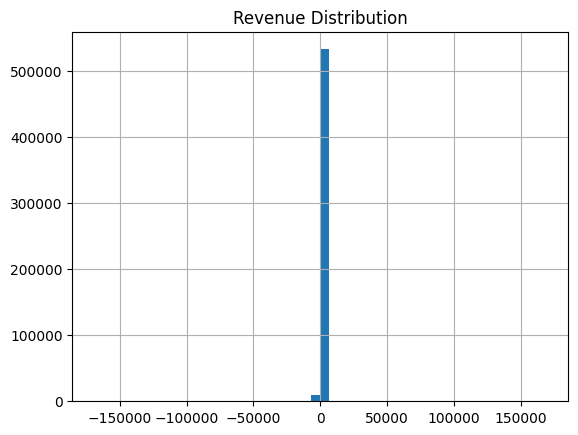

In [ ]:
import matplotlib.pyplot as plt

df['Revenue'].hist(bins=50)
plt.title('Revenue Distribution')
plt.show()

In [ ]:
df[df['UnitPrice'] < 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
299983,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom,-11062.06
299984,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom,-11062.06


### Revenue Distribution

Before aggregating revenue at the customer level, it is important to understand the distribution of transaction values and identify potential anomalies that could affect later analyses.

In [ ]:
df['Revenue'].describe()

,Revenue
count,541909.000000
mean,17.987795
std,378.810824
min,-168469.600000
25%,3.400000
50%,9.750000
75%,17.400000
max,168469.600000


### Initial Observations

The descriptive statistics reveal the presence of both positive and negative revenue values.

This indicates that not every transaction represents a successful sale. These negative values will be investigated further to determine whether they correspond to returns, cancellations, or data quality issues.

In [ ]:
df[df['Revenue'] == df['Revenue'].max()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2011-12-09 09:15:00,2.08,16446.0,United Kingdom,168469.6


In [ ]:
df[df['Revenue'] == df['Revenue'].min()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2011-12-09 09:27:00,2.08,16446.0,United Kingdom,-168469.6


### Revenue Distribution Analysis

Revenue values usually exhibit a highly skewed distribution due to the presence of a few very large transactions.

To improve visualization, a logarithmic transformation is applied to positive revenue values, allowing the distribution of typical transactions to be analyzed more effectively.

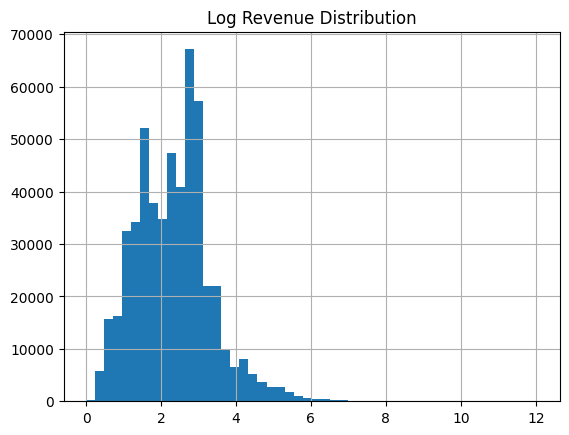

In [ ]:
import numpy as np

df[df['Revenue'] > 0]['Revenue'].apply(np.log1p).hist(bins=50)
plt.title('Log Revenue Distribution')
plt.show()

### Interpretation

After applying a logarithmic transformation to positive revenue values, the distribution becomes substantially more symmetric, making it easier to visualize the behavior of the majority of transactions.

The transformation reduces the influence of extremely large purchases while preserving the underlying purchasing patterns, which facilitates subsequent exploratory analysis.

# 4. Customer-Level Analysis

The previous analysis focused on individual transactions. However, Customer Lifetime Value (CLV) is calculated at the customer level rather than the transaction level.

Therefore, the next step is to aggregate transaction revenue by customer in order to understand how much revenue each customer has generated over the observation period.

In [ ]:
customer_revenue = df.groupby('CustomerID')['Revenue'].sum()

customer_revenue.head()

,Revenue
CustomerID,
12346.0,0.00
12347.0,4310.00
12348.0,1797.24
12349.0,1757.55
12350.0,334.40


### Distribution of Customer Revenue

This histogram shows the distribution of total revenue generated per customer.

Analyzing customer-level revenue helps identify whether sales are evenly distributed across customers or concentrated among a small subset of high-value customers.

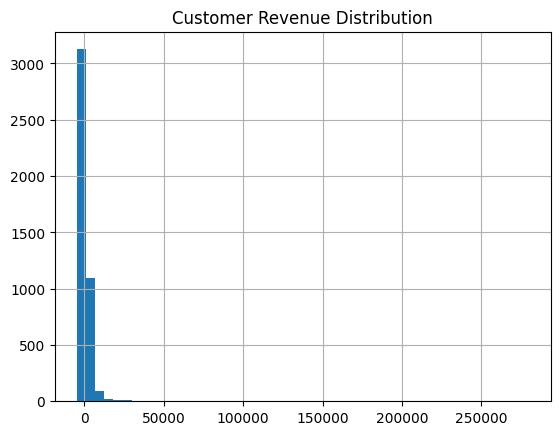

In [ ]:
customer_revenue.hist(bins=50)
plt.title('Customer Revenue Distribution')
plt.show()

### Interpretation

The distribution is highly right-skewed.

Most customers generate relatively low total revenue, while a small number of customers contribute disproportionately large amounts.

This concentration of revenue suggests that customer value is not evenly distributed across the customer base.

### Logarithmic Transformation

The extreme concentration of customer revenue makes it difficult to visualize the distribution.

Applying a logarithmic transformation compresses the scale of large values while preserving the relative ordering of customers, allowing the overall distribution to be analyzed more effectively.

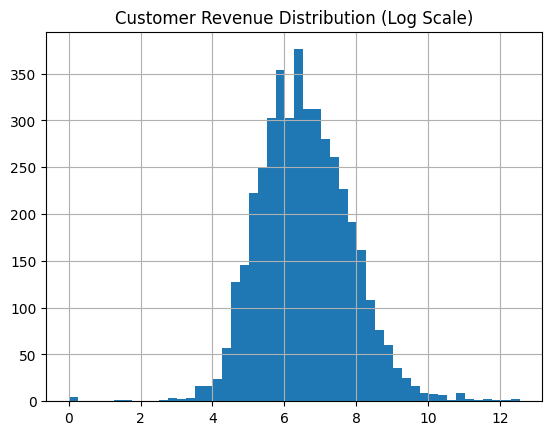

In [ ]:
import numpy as np

customer_revenue[customer_revenue > 0].apply(np.log1p).hist(bins=50)
plt.title('Customer Revenue Distribution (Log Scale)')
plt.show()

### Interpretation

After applying the logarithmic transformation, the customer revenue distribution becomes substantially more symmetric.

The visualization reveals that most customers are concentrated around intermediate revenue values, while only a few customers remain in the extreme tails of the distribution.

These high-revenue customers are likely to represent the company's most valuable customers and will play an important role in the subsequent Customer Lifetime Value analysis.

# 5. Customer Behavior Analysis

To better understand purchasing behavior, we analyze customer purchase frequency before constructing the variables required for Customer Lifetime Value modeling.

In [ ]:
customer_frequency = df.groupby('CustomerID')['InvoiceNo'].nunique()

customer_frequency.head()

,InvoiceNo
CustomerID,
12346.0,2
12347.0,7
12348.0,4
12349.0,1
12350.0,1


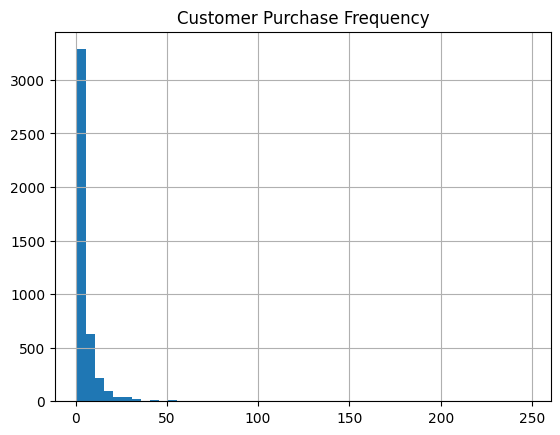

In [ ]:
customer_frequency.hist(bins=50)
plt.title('Customer Purchase Frequency')
plt.show()

### Interpretation

Customer purchase frequency is highly right-skewed.

Most customers purchase only a few times, while a relatively small number of customers make purchases much more frequently.

This suggests that repeat purchasing behavior is concentrated among a limited group of loyal customers.

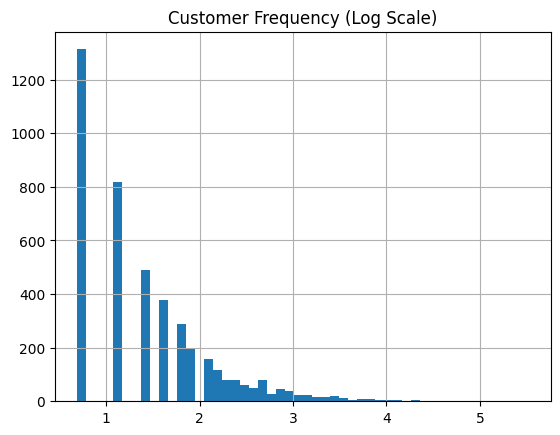

In [ ]:
customer_frequency[customer_frequency > 0].apply(np.log1p).hist(bins=50)
plt.title('Customer Frequency (Log Scale)')
plt.show()

### Interpretation

Applying the logarithmic transformation compresses extreme frequency values, allowing the overall distribution to be visualized more clearly.

Although the distribution remains right-skewed, the transformation highlights the purchasing behavior of the majority of customers.

In [ ]:
customer_monetary = df.groupby('CustomerID')['Revenue'].sum()

customer_monetary.head()

,Revenue
CustomerID,
12346.0,0.00
12347.0,4310.00
12348.0,1797.24
12349.0,1757.55
12350.0,334.40


### Customer Monetary Value

Monetary value represents the total revenue generated by each customer during the observation period.

Understanding this distribution helps identify whether customer spending is evenly distributed or concentrated among a small group of customers.

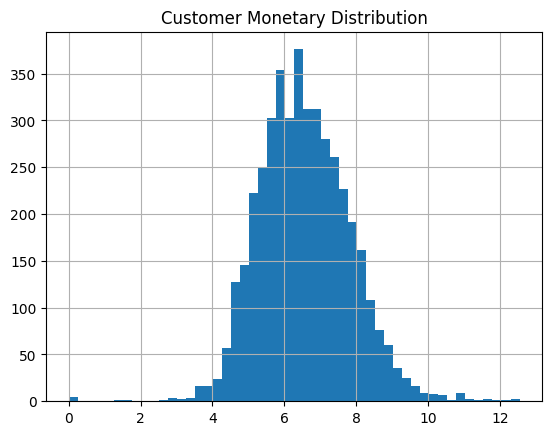

In [ ]:
import numpy as np

customer_monetary[customer_monetary > 0].apply(np.log1p).hist(bins=50)
plt.title('Customer Monetary Distribution')
plt.show()

### Interpretation

The logarithmic transformation reveals that most customers generate relatively modest monetary value, while only a limited number contribute substantially higher revenue.

This finding supports the idea that customer value is highly concentrated, which justifies estimating Customer Lifetime Value (CLV) at the individual customer level.

In [ ]:
df['InvoiceDate'].max()

Timestamp('2011-12-09 12:50:00')

In [ ]:
reference_date = df['InvoiceDate'].max()

customer_recency = df.groupby('CustomerID')['InvoiceDate'].max()

customer_recency = (reference_date - customer_recency).dt.days

customer_recency.head()

,InvoiceDate
CustomerID,
12346.0,325
12347.0,1
12348.0,74
12349.0,18
12350.0,309


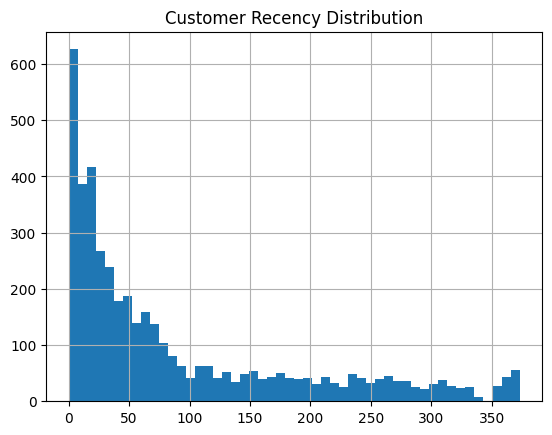

In [ ]:
customer_recency.hist(bins=50)
plt.title('Customer Recency Distribution')
plt.show()

### Interpretation

The recency distribution shows that a large proportion of customers made a purchase recently, while progressively fewer customers have longer periods since their last purchase.

This suggests that the dataset contains a considerable number of recently active customers, together with a smaller group that has not purchased for a long time.

In [ ]:
rfm = pd.DataFrame({
    'Recency': customer_recency,
    'Frequency': customer_frequency,
    'Monetary': customer_monetary
})

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,325,2,0.00
12347.0,1,7,4310.00
12348.0,74,4,1797.24
12349.0,18,1,1757.55
12350.0,309,1,334.40


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary
count,4372.000000,4372.000000,4372.000000
mean,91.047118,5.075480,1898.459701
std,100.765435,9.338754,8219.345141
min,0.000000,1.000000,-4287.630000
25%,16.000000,1.000000,293.362500
50%,49.000000,3.000000,648.075000
75%,142.000000,5.000000,1611.725000
max,373.000000,248.000000,279489.020000


### RFM Summary

The descriptive statistics highlight several key observations:

- Some customers made purchases on the most recent day of the observation period (`Recency = 0`).
- Purchase frequency varies considerably, ranging from one purchase to highly frequent customers.
- Negative monetary values are present, indicating that returned transactions are still included at this stage and will be addressed before CLV modeling.

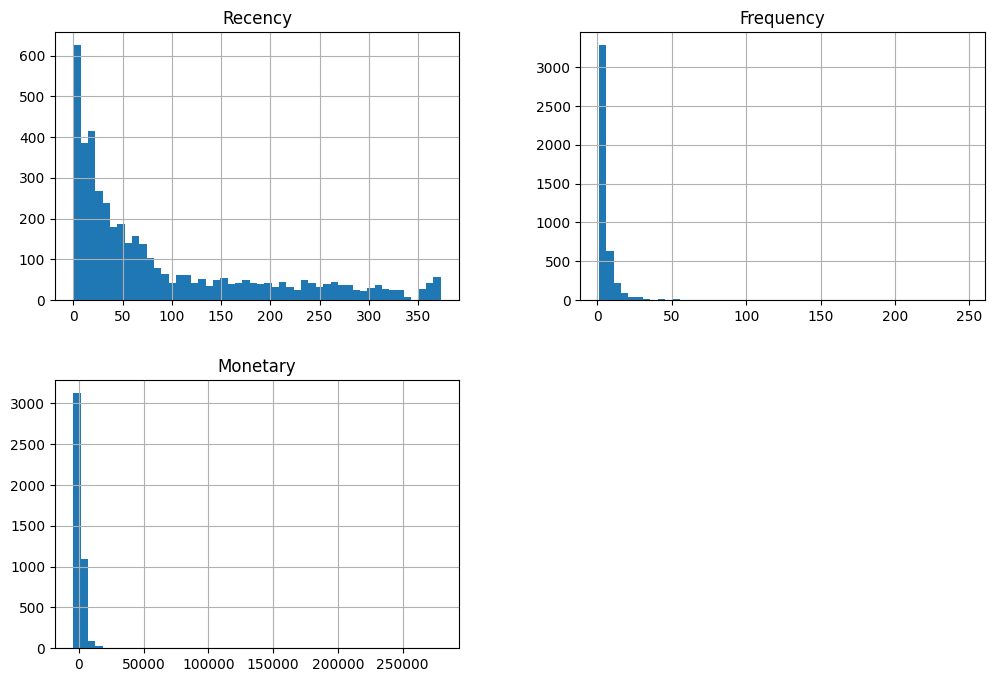

In [ ]:
rfm.hist(bins=50, figsize=(12,8))
plt.show()

### Interpretation

The three distributions exhibit different customer behaviors:

- **Recency:** many customers purchased recently, while fewer customers have been inactive for long periods.
- **Frequency:** most customers purchase only a small number of times, whereas a limited group purchases very frequently.
- **Monetary:** customer spending is highly concentrated, with most customers generating relatively low revenue and a small number contributing substantially higher amounts.

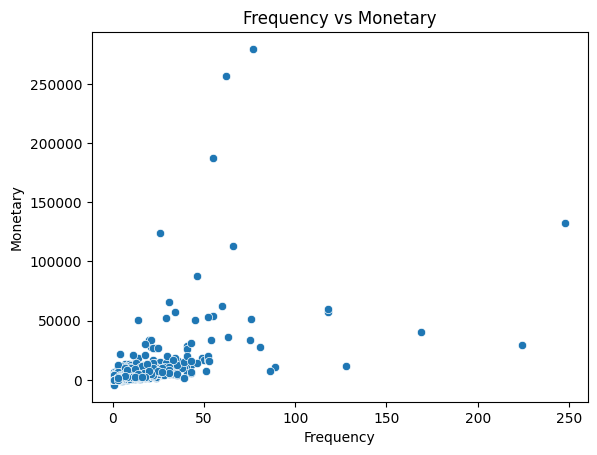

In [ ]:
import seaborn as sns

sns.scatterplot(data=rfm, x='Frequency', y='Monetary')
plt.title('Frequency vs Monetary')
plt.show()

### Relationship Between Frequency and Monetary Value

The scatter plot suggests a positive relationship between purchase frequency and monetary value.

Customers who purchase more frequently tend to generate higher revenue; however, the relationship is not perfectly linear.

Some customers spend considerably more despite having fewer purchases, indicating that purchase value also plays an important role in Customer Lifetime Value.

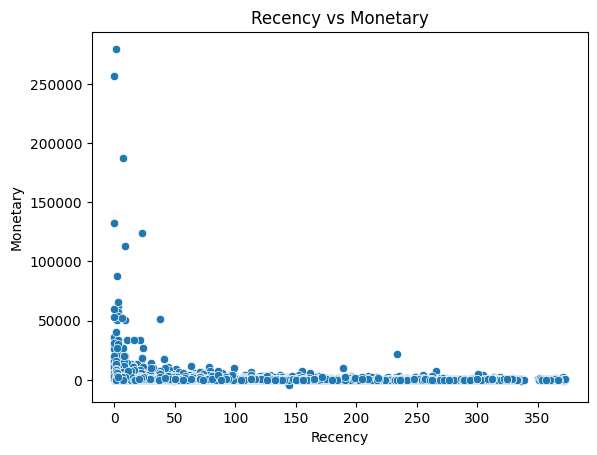

In [ ]:
sns.scatterplot(data=rfm, x='Recency', y='Monetary')
plt.title('Recency vs Monetary')
plt.show()

### Relationship Between Recency and Monetary Value

Most customers generate relatively low monetary value regardless of their recency. However, the highest-spending customers are concentrated among those with lower recency values, meaning they purchased more recently.

This suggests a weak negative relationship between recency and spending: customers who purchased recently tend to generate higher monetary value, although the relationship is not strong.

In [ ]:
rfm.corr()

,Recency,Frequency,Monetary
Recency,1.000000,-0.259342,-0.132001
Frequency,-0.259342,1.000000,0.566122
Monetary,-0.132001,0.566122,1.000000


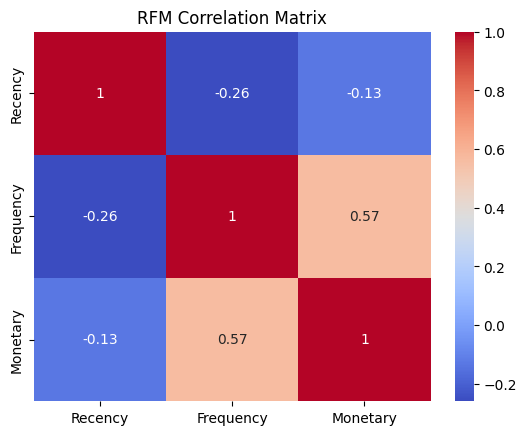

In [ ]:
import seaborn as sns

sns.heatmap(rfm.corr(), annot=True, cmap='coolwarm')
plt.title('RFM Correlation Matrix')
plt.show()

### Correlation Analysis

The strongest relationship is observed between **Frequency** and **Monetary** (≈ 0.57), indicating that customers who purchase more frequently also tend to generate higher revenue.

Both **Recency–Frequency** and **Recency–Monetary** show weak negative correlations. This suggests that customers who purchased more recently generally buy more often and spend slightly more, although these relationships are considerably weaker.

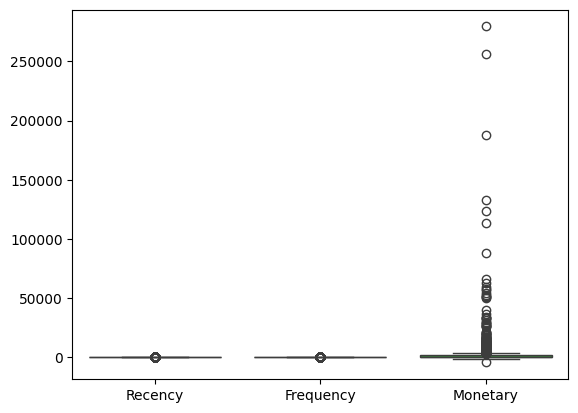

In [ ]:
import seaborn as sns

sns.boxplot(data=rfm[['Recency','Frequency','Monetary']])
plt.show()

### Outlier Analysis

The boxplots reveal that **Monetary** contains several extreme values, whereas **Recency** and **Frequency** exhibit comparatively fewer visible outliers.

These high-spending customers are expected in retail businesses and may represent genuinely valuable customers rather than data quality issues. Therefore, they should be carefully evaluated before deciding whether to remove them during data preparation.

# 6. Preparing Data for CLV Modeling

The exploratory analysis is complete.

The next step is to prepare the customer-level data required by the BG/NBD and Gamma-Gamma models, which estimate future purchasing behavior and Customer Lifetime Value.

In [ ]:
snapshot_date = df['InvoiceDate'].max()
snapshot_date

Timestamp('2011-12-09 12:50:00')

### Snapshot Date

The snapshot date corresponds to the most recent transaction available in the dataset.

It serves as the reference point for calculating customer recency and the observation period (T), which are required inputs for the BG/NBD model.

In [ ]:
rfm['T'] = (snapshot_date - df.groupby('CustomerID')['InvoiceDate'].min()).dt.days

In [ ]:
first_purchase = df.groupby('CustomerID')['InvoiceDate'].min()
first_purchase.head()

,InvoiceDate
CustomerID,
12346.0,2011-01-18 10:01:00
12347.0,2010-12-07 14:57:00
12348.0,2010-12-16 19:09:00
12349.0,2011-11-21 09:51:00
12350.0,2011-02-02 16:01:00


### Calculating the Observation Period (T)

The BG/NBD model requires the observation period for each customer.

T represents the number of days between a customer's first purchase and the snapshot date, indicating how long each customer has been observed.

In [ ]:
rfm['T'] = (snapshot_date - first_purchase).dt.days

In [ ]:
rfm.head()

,Recency,Frequency,Monetary,T
CustomerID,,,,
12346.0,325,2,0.00,325
12347.0,1,7,4310.00,366
12348.0,74,4,1797.24,357
12349.0,18,1,1757.55,18
12350.0,309,1,334.40,309


In [ ]:
rfm.describe()

,Recency,Frequency,Monetary,T
count,4372.000000,4372.000000,4372.000000,4372.000000
mean,91.047118,5.075480,1898.459701,224.779048
std,100.765435,9.338754,8219.345141,118.412473
min,0.000000,1.000000,-4287.630000,0.000000
25%,16.000000,1.000000,293.362500,114.000000
50%,49.000000,3.000000,648.075000,252.000000
75%,142.000000,5.000000,1611.725000,331.000000
max,373.000000,248.000000,279489.020000,373.000000


### Validation

The calculated values are consistent with the dataset.

The observation period (T) ranges from 0 to 373 days, indicating that some customers made their first purchase on the final day of the observation period, while others have been active throughout almost the entire year.

In [ ]:
(rfm['Recency'] > rfm['T']).sum()

np.int64(0)

### Data Validation

A fundamental assumption of the BG/NBD model is that customer recency cannot exceed the observation period (T).

The validation returned zero violations, confirming that the dataset satisfies this modeling requirement.

### Filtering Eligible Customers

The BG/NBD model can only estimate future purchasing behavior for repeat customers.

Therefore, customers with only one observed purchase are excluded because their repeat purchasing behavior cannot yet be estimated.

In [ ]:
rfm = rfm[rfm['Frequency'] > 0]

In [ ]:
rfm.shape

(4372, 4)

In [ ]:
!pip install lifetimes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 584.2/584.2 kB 10.2 MB/s eta 0:00:00


In [ ]:
from lifetimes import BetaGeoFitter
from lifetimes import GammaGammaFitter

# 7. Building the BG/NBD Model

The `summary_data_from_transaction_data()` function from the **lifetimes** package automatically prepares the customer-level dataset required by the BG/NBD model.

It computes the following variables for each customer:

- **Frequency:** number of repeat purchases.
- **Recency:** time between the first and last purchase.
- **T:** observation period from the first purchase until the snapshot date.
- **Monetary Value:** average revenue per transaction.

In [ ]:
from lifetimes.utils import summary_data_from_transaction_data

rfm = summary_data_from_transaction_data(
    df,
    'CustomerID',
    'InvoiceDate',
    monetary_value_col='Revenue',
    observation_period_end=snapshot_date
)

rfm.head()

,frequency,recency,T,monetary_value
CustomerID,,,,
12346.0,0.0,0.0,325.0,0.000000
12347.0,6.0,365.0,367.0,599.701667
12348.0,3.0,283.0,358.0,301.480000
12349.0,0.0,0.0,18.0,0.000000
12350.0,0.0,0.0,310.0,0.000000


### Model Training

The BG/NBD model is trained using customer purchase history.

Unlike traditional machine learning algorithms, this probabilistic model estimates the likelihood that a customer remains active and predicts the expected number of future purchases based on historical purchasing behavior.

In [ ]:
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(rfm['frequency'], rfm['recency'], rfm['T'])

<lifetimes.BetaGeoFitter: fitted with 4372 subjects, a: 0.01, alpha: 52.85, b: 0.24, r: 0.80>

In [ ]:
bgf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
r,0.800716,0.023574,0.754511,0.846921
alpha,52.847865,1.927483,49.069999,56.625731
a,0.012224,0.003367,0.005625,0.018822
b,0.240658,0.062101,0.118940,0.362376


### Model Parameters

The BG/NBD model successfully converged after applying a penalizer coefficient.

The estimated parameters describe the overall purchasing behavior of the customer base and will be used to predict future transactions and customer retention probabilities.

### Predicting Future Purchases

Using the fitted BG/NBD model, we estimate the expected number of purchases each customer is likely to make during the next **30 days**.

In [ ]:
rfm['predicted_purchases'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    30,
    rfm['frequency'],
    rfm['recency'],
    rfm['T']
)

In [ ]:
rfm.head()

,frequency,recency,T,monetary_value,predicted_purchases
CustomerID,,,,,
12346.0,0.0,0.0,325.0,0.000000,0.063367
12347.0,6.0,365.0,367.0,599.701667,0.484517
12348.0,3.0,283.0,358.0,301.480000,0.274133
12349.0,0.0,0.0,18.0,0.000000,0.334282
12350.0,0.0,0.0,310.0,0.000000,0.065978


In [ ]:
rfm.sort_values('predicted_purchases', ascending=False).head(10)

,frequency,recency,T,monetary_value,predicted_purchases
CustomerID,,,,,
14911.0,145.0,372.0,373.0,910.463724,10.265733
12748.0,114.0,373.0,373.0,254.975000,8.083126
17841.0,112.0,372.0,373.0,355.421429,7.942025
15311.0,90.0,373.0,373.0,655.266778,6.393089
14606.0,88.0,372.0,373.0,130.858295,6.252049
13089.0,82.0,367.0,369.0,690.871707,5.884571
12971.0,71.0,369.0,372.0,153.311831,5.066451
16422.0,66.0,352.0,369.0,486.931667,4.734670
14527.0,63.0,371.0,373.0,122.839365,4.491486


### Top Customers by Expected Purchases

The ranking highlights the customers with the highest predicted purchasing activity over the next month.

These customers represent strong candidates for loyalty programs, personalized marketing campaigns, and customer retention initiatives.

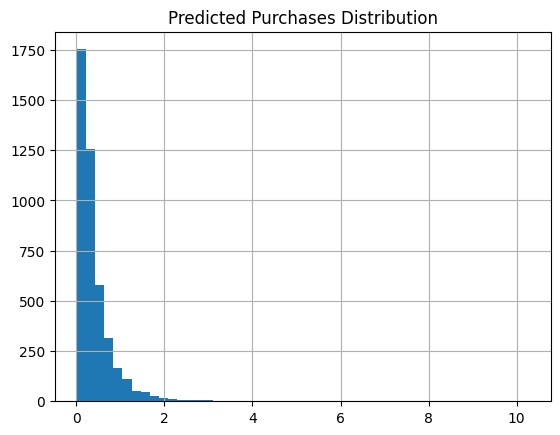

In [ ]:
import matplotlib.pyplot as plt

rfm['predicted_purchases'].hist(bins=50)
plt.title('Predicted Purchases Distribution')
plt.show()

### Distribution of Expected Purchases

Most customers are expected to make relatively few purchases during the next 30 days, while only a small number are predicted to purchase frequently.

This behavior is consistent with the purchasing patterns typically observed in retail datasets.

### Estimating Customer Survival Probability

The BG/NBD model also estimates the probability that each customer is still active.

A probability close to **1** indicates that the customer is very likely to make future purchases, whereas values closer to **0** suggest a higher risk of churn.

In [ ]:
rfm['probability_alive'] = bgf.conditional_probability_alive(
    rfm['frequency'],
    rfm['recency'],
    rfm['T']
)

In [ ]:
rfm.head()

,frequency,recency,T,monetary_value,predicted_purchases,probability_alive
CustomerID,,,,,,
12346.0,0.0,0.0,325.0,0.000000,0.063367,1.000000
12347.0,6.0,365.0,367.0,599.701667,0.484517,0.997596
12348.0,3.0,283.0,358.0,301.480000,0.274133,0.988400
12349.0,0.0,0.0,18.0,0.000000,0.334282,1.000000
12350.0,0.0,0.0,310.0,0.000000,0.065978,1.000000


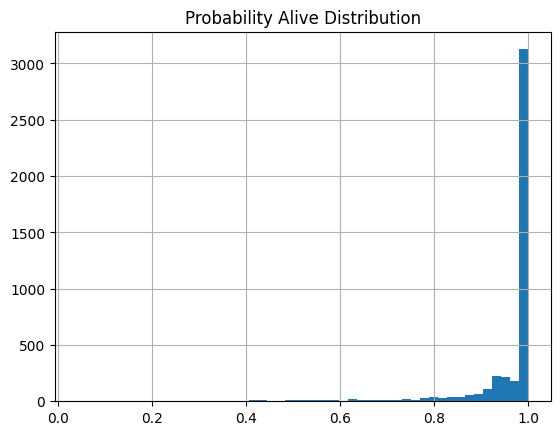

In [ ]:
rfm['probability_alive'].hist(bins=50)
plt.title('Probability Alive Distribution')
plt.show()

### Interpretation

Most customers have a probability close to **1**, suggesting that the majority are still considered active by the model.

A smaller group exhibits much lower probabilities, identifying customers who may require retention strategies to reduce churn risk.

In [ ]:
rfm[['frequency','monetary_value']].describe()

,frequency,monetary_value
count,4372.000000,4372.000000
mean,3.413541,213.254316
std,6.674343,372.810217
min,0.000000,-3528.340000
25%,0.000000,0.000000
50%,1.000000,148.955000
75%,4.000000,304.942500
max,145.000000,8866.081538


### Preparing Data for the Gamma-Gamma Model

The Gamma-Gamma model assumes that all customers have positive average monetary values.

Therefore, we first identify customers with non-positive monetary values before fitting the model.

In [ ]:
(rfm['monetary_value'] <= 0).sum()

np.int64(1576)

In [ ]:
rfm_gg = rfm[rfm['monetary_value'] > 0]

### Filtering Eligible Customers

Customers with zero or negative average monetary values are excluded because they do not satisfy the assumptions required by the Gamma-Gamma model.

In [ ]:
rfm_gg.shape

(2796, 6)

# 8. Gamma-Gamma Model

The Gamma-Gamma model estimates the expected average monetary value of future purchases.

Unlike the BG/NBD model, which predicts **how often** customers will purchase, the Gamma-Gamma model predicts **how much they are expected to spend**.

In [ ]:
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(rfm_gg['frequency'], rfm_gg['monetary_value'])

<lifetimes.GammaGammaFitter: fitted with 2796 subjects, p: 3.79, q: 0.36, v: 3.69>

In [ ]:
ggf.summary

,coef,se(coef),lower 95% bound,upper 95% bound
p,3.792282,0.096405,3.603328,3.981236
q,0.357821,0.007701,0.342727,0.372915
v,3.689081,0.097430,3.498119,3.880043


### Model Parameters

The Gamma-Gamma model successfully converged after applying regularization.

The estimated parameters characterize the spending behavior of repeat customers and are used to estimate future average transaction values.

### Predicting Customer Spending

Using the fitted Gamma-Gamma model, we estimate the expected average monetary value of future purchases for each customer.

In [ ]:
rfm_gg['predicted_monetary'] = ggf.conditional_expected_average_profit(
    rfm_gg['frequency'],
    rfm_gg['monetary_value']
)

In [ ]:
rfm_gg.head()

,frequency,recency,T,monetary_value,predicted_purchases,probability_alive,predicted_monetary
CustomerID,,,,,,,
12347.0,6.0,365.0,367.0,599.701667,0.484517,0.997596,617.751361
12348.0,3.0,283.0,358.0,301.480000,0.274133,0.988400,320.818678
12352.0,6.0,260.0,296.0,208.151667,0.581628,0.995132,214.829669
12356.0,2.0,303.0,325.0,269.905000,0.219633,0.988479,296.886715
12358.0,1.0,149.0,150.0,683.200000,0.252860,0.951251,826.918156


# 9. Customer Lifetime Value (CLV)

The final Customer Lifetime Value is obtained by combining the BG/NBD and Gamma-Gamma models.

- **BG/NBD** estimates how many future purchases a customer is expected to make.
- **Gamma-Gamma** estimates the expected average value of each purchase.

Together, these models estimate the total revenue each customer is expected to generate over the next **six months**.

In [ ]:
rfm_gg['clv'] = ggf.customer_lifetime_value(
    bgf,
    rfm_gg['frequency'],
    rfm_gg['recency'],
    rfm_gg['T'],
    rfm_gg['monetary_value'],
    time=6,  # meses
    freq='D',
    discount_rate=0.01
)

In [ ]:
rfm_gg.head()

,frequency,recency,T,monetary_value,predicted_purchases,probability_alive,predicted_monetary,clv
CustomerID,,,,,,,,
12347.0,6.0,365.0,367.0,599.701667,0.484517,0.997596,617.751361,1730.737202
12348.0,3.0,283.0,358.0,301.480000,0.274133,0.988400,320.818678,508.338055
12352.0,6.0,260.0,296.0,208.151667,0.581628,0.995132,214.829669,722.244407
12356.0,2.0,303.0,325.0,269.905000,0.219633,0.988479,296.886715,376.690097
12358.0,1.0,149.0,150.0,683.200000,0.252860,0.951251,826.918156,1204.001131


In [ ]:
rfm_gg.sort_values('clv', ascending=False).head(10)

,frequency,recency,T,monetary_value,predicted_purchases,probability_alive,predicted_monetary,clv
CustomerID,,,,,,,,
14646.0,46.0,353.0,354.0,6074.305652,3.448361,0.999697,6096.829937,121604.930661
18102.0,26.0,367.0,367.0,8866.081538,1.913240,0.999516,8924.347873,98760.977577
17450.0,32.0,359.0,367.0,5795.416563,2.340989,0.999265,5826.363962,78894.017077
14096.0,16.0,97.0,101.0,3568.791875,3.268024,0.998753,3607.199804,68015.597582
12415.0,17.0,313.0,337.0,6865.533529,1.365951,0.997673,6934.828975,54781.247779
14911.0,145.0,372.0,373.0,910.463724,10.265733,0.999881,911.553726,54132.165745
14156.0,50.0,363.0,372.0,2267.832800,3.583019,0.999264,2275.613561,47164.499611
17511.0,32.0,371.0,373.0,2696.863750,2.308663,0.999544,2711.326909,36207.601768
16684.0,17.0,354.0,358.0,3832.518824,1.298025,0.999105,3871.298170,29063.052997


### Customers with the Highest Lifetime Value

The ranking identifies the customers expected to generate the highest long-term revenue.

These customers should be considered strategic assets and prioritized through loyalty programs, personalized communication, and premium customer experiences.

<Axes: >

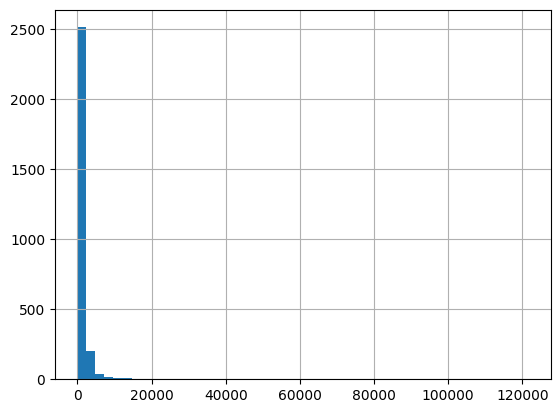

In [ ]:
rfm_gg['clv'].hist(bins=50)

### CLV Distribution

Customer Lifetime Value is highly right-skewed.

Most customers generate relatively low lifetime value, while a small group of customers contributes disproportionately high long-term revenue.

In [ ]:
rfm_gg['clv'].describe()

,clv
count,2796.000000
mean,1365.857857
std,4404.448195
min,3.376635
25%,323.432253
50%,660.471597
75%,1325.066827
max,121604.930661


### Summary Statistics

The average predicted Customer Lifetime Value is approximately **1,366 monetary units**, although the distribution is highly dispersed.

The maximum predicted CLV exceeds **120,000**, highlighting the presence of a small group of exceptionally valuable customers.

# 10. Customer Segmentation

To facilitate business decision-making, customers are segmented into four groups according to their predicted Customer Lifetime Value.

This segmentation enables marketing teams to prioritize customers and design differentiated retention strategies.

In [ ]:
rfm_gg['segment'] = pd.qcut(
    rfm_gg['clv'],
    q=4,
    labels=['Low Value', 'Mid Value', 'High Value', 'VIP']
)

### Initial CLV Segmentation (Quartiles)

Customers are initially divided into four equally sized groups using CLV quartiles. This segmentation is useful for comparing customer profiles but does not represent the actual business distribution of customers.

In [ ]:
rfm_gg['segment'].value_counts()

,count
segment,
Low Value,699
Mid Value,699
High Value,699
VIP,699


In [ ]:
rfm_gg.groupby('segment')['clv'].mean()

,clv
segment,
Low Value,183.420006
Mid Value,476.619746
High Value,940.776929
VIP,3862.614748


<Axes: xlabel='segment'>

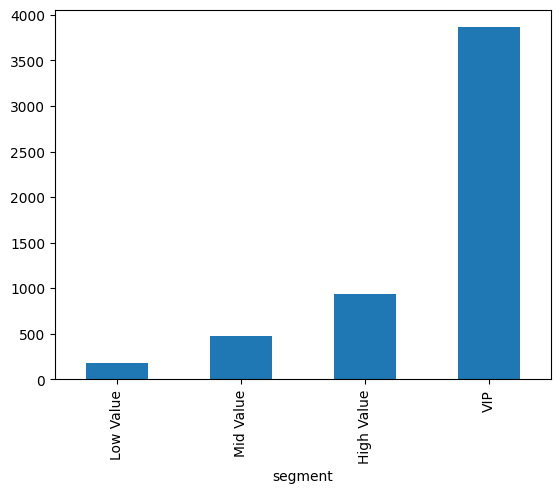

In [ ]:
rfm_gg.groupby('segment')['clv'].mean().plot(kind='bar')

Although quartile segmentation is useful for analysis, every segment contains the same number of customers by design.

To better represent the business reality, a custom business-oriented segmentation is created in the next section.

In [ ]:
rfm_gg.groupby('segment')[['frequency','monetary_value','clv']].mean()

,frequency,monetary_value,clv
segment,,,
Low Value,1.928469,138.414437,183.420006
Mid Value,3.092990,242.169083,476.619746
High Value,4.741059,338.604423,940.776929
VIP,11.264664,637.808365,3862.614748


## Business Recommendations

### VIP Customers
**Objective:** Retain the most valuable customers.

Recommended actions:
- Offer exclusive loyalty rewards.
- Provide personalized communication.
- Grant early access to new products or promotions.
- Deliver premium customer support.

---

### High Value Customers
**Objective:** Increase Customer Lifetime Value.

Recommended actions:
- Apply cross-selling strategies.
- Recommend complementary products.
- Offer personalized promotions.
- Encourage higher purchase frequency.

---

### Mid Value Customers
**Objective:** Increase purchase frequency.

Recommended actions:
- Send email marketing campaigns.
- Provide discount coupons.
- Recommend relevant products based on purchase history.

---

### Low Value Customers
**Objective:** Reactivate inactive customers.

Recommended actions:
- Launch reactivation campaigns.
- Offer time-limited discounts.
- Apply remarketing strategies.
- Encourage a new purchase with introductory offers.

In [ ]:
rfm_gg['segment_business'] = pd.cut(
    rfm_gg['clv'],
    bins=[0, 500, 1500, 5000, rfm_gg['clv'].max()],
    labels=['Low Value', 'Mid Value', 'High Value', 'VIP']
)

## Business-Oriented Customer Segmentation

Unlike quartile segmentation, this classification reflects the actual distribution of customers based on their estimated Customer Lifetime Value.

The thresholds were selected to create actionable business segments that allow marketing teams to prioritize customer retention and acquisition strategies.

In [ ]:
rfm_gg['segment_business'].value_counts()

,count
segment_business,
Low Value,1125
Mid Value,1088
High Value,500
VIP,83


### Interpretation

The customer base is concentrated in the Low Value and Mid Value segments.

Only a small number of customers belong to the VIP segment, highlighting that highly valuable customers are scarce and should receive special attention through personalized retention programs.

In [ ]:
rfm_gg.groupby('segment_business')['clv'].agg(['count','mean','sum'])

,count,mean,sum
segment_business,,,
Low Value,1125,270.030672,3.037845e+05
Mid Value,1088,899.491512,9.786468e+05
High Value,500,2437.666696,1.218833e+06
VIP,83,15875.589757,1.317674e+06


### Business Insight

Although VIP customers represent only 83 customers, they generate the highest cumulative Customer Lifetime Value.

This finding illustrates the Pareto principle commonly observed in retail, where a relatively small percentage of customers contributes a disproportionately large share of future revenue.

These customers should be considered strategic assets for the business.

<Axes: xlabel='segment_business'>

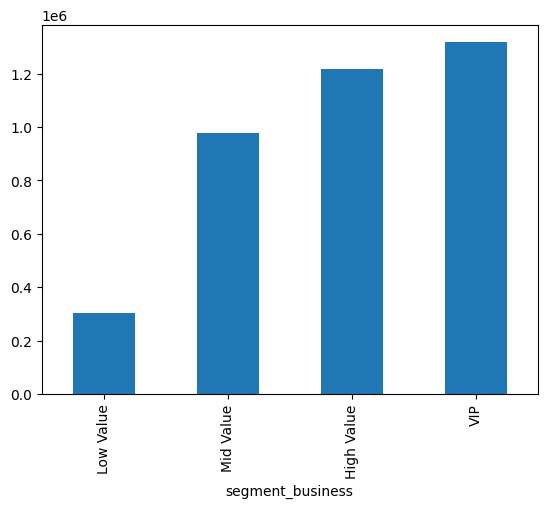

In [ ]:
rfm_gg.groupby('segment_business')['clv'].sum().plot(kind='bar')

In [ ]:
top_customers = rfm_gg.sort_values('clv', ascending=False).head(20)
top_customers

,frequency,recency,T,monetary_value,predicted_purchases,probability_alive,predicted_monetary,clv,segment,segment_business
CustomerID,,,,,,,,,,
14646.0,46.0,353.0,354.0,6074.305652,3.448361,0.999697,6096.829937,121604.930661,VIP,VIP
18102.0,26.0,367.0,367.0,8866.081538,1.913240,0.999516,8924.347873,98760.977577,VIP,VIP
17450.0,32.0,359.0,367.0,5795.416563,2.340989,0.999265,5826.363962,78894.017077,VIP,VIP
14096.0,16.0,97.0,101.0,3568.791875,3.268024,0.998753,3607.199804,68015.597582,VIP,VIP
12415.0,17.0,313.0,337.0,6865.533529,1.365951,0.997673,6934.828975,54781.247779,VIP,VIP
14911.0,145.0,372.0,373.0,910.463724,10.265733,0.999881,911.553726,54132.165745,VIP,VIP
14156.0,50.0,363.0,372.0,2267.832800,3.583019,0.999264,2275.613561,47164.499611,VIP,VIP
17511.0,32.0,371.0,373.0,2696.863750,2.308663,0.999544,2711.326909,36207.601768,VIP,VIP
16684.0,17.0,354.0,358.0,3832.518824,1.298025,0.999105,3871.298170,29063.052997,VIP,VIP


### Interpretation

The ranking confirms that Customer Lifetime Value is influenced by multiple factors.

Customers with the highest CLV are not necessarily those with the highest purchase frequency alone.

Purchase frequency, monetary value, and the probability of remaining active jointly determine the future economic value of each customer.

In [ ]:
rfm_gg.to_csv('customer_clv_segmentation.csv')

<Axes: xlabel='segment_business'>

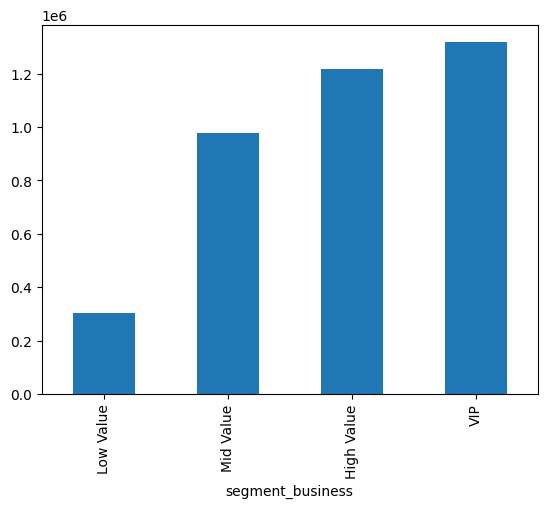

In [ ]:
rfm_gg.groupby('segment_business')['clv'].sum().plot(kind='bar')

<Axes: >

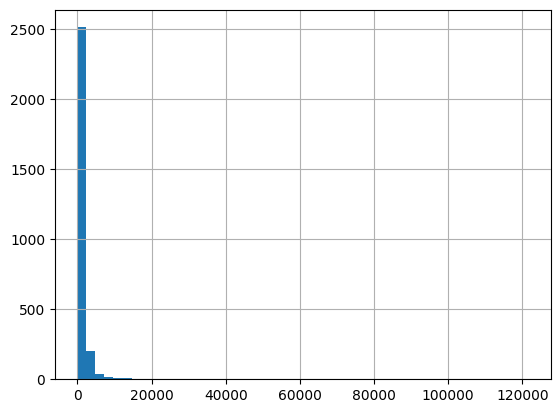

In [ ]:
rfm_gg['clv'].hist(bins=50)

### Interpretation

The CLV distribution is highly right-skewed.

Most customers generate relatively low expected lifetime value, while a small number of customers contribute exceptionally high future revenue.

This confirms that customer value is unevenly distributed across the customer base.

<Axes: >

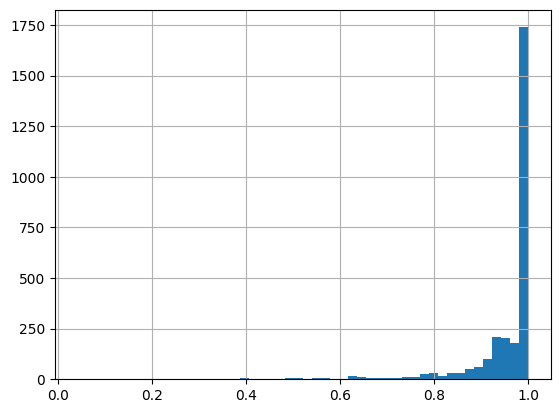

In [ ]:
rfm_gg['probability_alive'].hist(bins=50)

### Interpretation

Most customers have a high probability of remaining active.

This suggests that the historical purchasing behavior captured by the BG/NBD model indicates a generally healthy customer base with relatively low expected churn.

In [ ]:
rfm_gg['risk_segment'] = 'Other'

rfm_gg.loc[
    (rfm_gg['clv'] > 1500) & (rfm_gg['probability_alive'] > 0.8),
    'risk_segment'
] = 'VIP Loyal'

rfm_gg.loc[
    (rfm_gg['clv'] > 1500) & (rfm_gg['probability_alive'] <= 0.8),
    'risk_segment'
] = 'VIP At Risk'

rfm_gg.loc[
    (rfm_gg['clv'] <= 1500) & (rfm_gg['probability_alive'] > 0.8),
    'risk_segment'
] = 'Potential'

rfm_gg.loc[
    (rfm_gg['clv'] <= 1500) & (rfm_gg['probability_alive'] <= 0.8),
    'risk_segment'
] = 'Low Value / Churn Risk'

In [ ]:
rfm_gg['risk_segment'].value_counts()

,count
risk_segment,
Potential,2050
VIP Loyal,580
Low Value / Churn Risk,163
VIP At Risk,3


### Business Interpretation

The majority of customers fall into the Potential segment, representing opportunities for future growth through personalized marketing campaigns.

The 580 VIP Loyal customers should remain a strategic priority, as retaining them maximizes future revenue.

Although only three customers are classified as VIP At Risk, losing any of them could represent a significant financial impact due to their high expected lifetime value.

# Final Conclusions

This project demonstrates how probabilistic models can estimate future customer behavior using historical transactional data.

The BG/NBD model was successfully applied to estimate purchase frequency and customer survival probability, while the Gamma-Gamma model estimated the expected monetary value of future purchases.

Combining both models allowed the calculation of Customer Lifetime Value (CLV), enabling customers to be segmented according to their long-term business value.

The analysis revealed that:

- Most customers generate relatively low lifetime value.
- A small group of VIP customers contributes a disproportionately large share of future revenue.
- Most customers have a high probability of remaining active.
- A small number of high-value customers are at risk of churn and should receive immediate retention actions.

These insights can support marketing teams in prioritizing customer retention, loyalty programs, cross-selling, and personalized campaigns to maximize long-term profitability.

# Project Summary

### Techniques Used

- Exploratory Data Analysis (EDA)
- Customer-level feature engineering
- BG/NBD probabilistic model
- Gamma-Gamma monetary model
- Customer Lifetime Value (CLV)
- Customer Segmentation
- Business Recommendations

### Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Lifetimes

### Business Outcome

The project provides a data-driven framework for estimating future customer value and prioritizing marketing actions based on predicted customer behavior.